In [1]:
from HARey_constellation_cards.harey_main import HAReyMain
from HARey_constellation_cards.astro_projection import local2equator, stereo_polar, azimuthal_polar, stereo_radius, azimuthal_radius
import matplotlib.pyplot as plt
import numpy as np

harey = HAReyMain()

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at cardbacks/tarot_round.png


# Astrolabes and planispheres

The astrolabe is one of the oldest astronomical insteruments, dating back to the classic antiquity. It served as star chart showing the visible half-dome of the sky, and a as a trigonometric computer.

## How they are made

The astrolabe was born as flat projections of an armillary sphere, which was composed of several rings which represented the horizon, the ecliptic and the celestial equator.

The astrolabe projects the sky as seen from the Earth poles. In this way, the rotation of the stars is perfectly represented by rotating the "Earth" disk or the "Sky" disk around the center, a turn every 24 h. 
The "Earth" disk is the one over which the local meridians and almucantarats, which are the vertical and horizontal circles that divide the local sky dome. This enabled the possesor of an astrolabe to calculate where a star would in its own altitude-azimuth reference frame.

The "Sky" projection once had to be made out of thin metal shapes, to not obstruct view of the "Earth" disk below, which was then called "Mater". The "Rete" could only show the ecliptic plane and the position of few bright stars. By knowing the precise poistion of the Sun on the ecliptic ring and the position of a star in the sky, the astrolabe enabled people to precisely compute the local time.

Ancient astrolabes were made out of copper or bronze and were rigthfully considered artpieces. 

## How an astrolabe work

As said before, the key to everything an astrolabe can do resides in the projection done around the Earth rotation axis. The projection used was a stereographic, as it is a conformal projection: it does not distort shapes, and so circles are projected in circles. As meridians and almucantarats are circle, this made the construction process somewhat easier. 

Considering the Mater as fixed, which avoids thinking about a rotating Earth and giving us an headache, the astrolabe works in this way: the Mater shows the horizon, the zenith and the four cardinal points. To be noted the fact that they are not in the usual order: when North is up, East and West are on the opposite sides than they are on maps. In fact, maps are to be seen from above, while the astrolabe is intended to be held above your head toward the sky.

The Rete completes one rotation every 23h 56min, from East to West. This means that as time goes by, a star on the rete moves counterclockwise. The time is kept by a ring on the Mater, which displays 24 hours, with the 12 towards South, in a couterclokwise faction. The stars take less than 24 hours (the difference between a sidereal and a mean solar day is about 4 minutes), so after a day the star has moved a little more counterclockwise than the point in which it where. After a whole 24 hours the point that was at 12 before is clockwise from the one before. This difference adds up day after day and is displayed as a clockwise calendar on the mater, starting from the Spring equinox (which is the reference point for 0 RA). 

...This is how it it for folks in the Northern emisphere. South of the equator, North and South swap and the hour and calendar rings change direction...

## A matter of projections

The historical stereographic projection preserves shapes and make it possible to create a Mater only with compass, ruler, and very little trigonometry, but for latitudes close to the equator the projection on the mother becomes so distant from the center that a very large Rete is needed to cover the constellations that are close to the horizon. 

For this reason almost every astrolabe does not cover the whole celestial dome, and astrolabes do not work near the equator. Also the stereographic projection creates consellations that are smaller and smaller towards the center, making distinguish features difficult.

More recently, planisphere were created to circumvent this problem: they are astrolabes which use an azimuthal projection. This does not grow as fast as the stereographic does, but this comes with the cost of more distorted costellations. Also, the projection has to be handled by the computer.

The following plot shows the matr and the rete meridians and almucantarats for 70°N and 40°N. The solid line is the horizon (0° alucantarat). It shows how nearing the equator cretaes a projected horizon on the mother which is bigger and bigger, requiring a bigger rete to show the stars in the south. The azimutal projection enables a smaller rete to cover more sky, at the cost of distoring the projection.

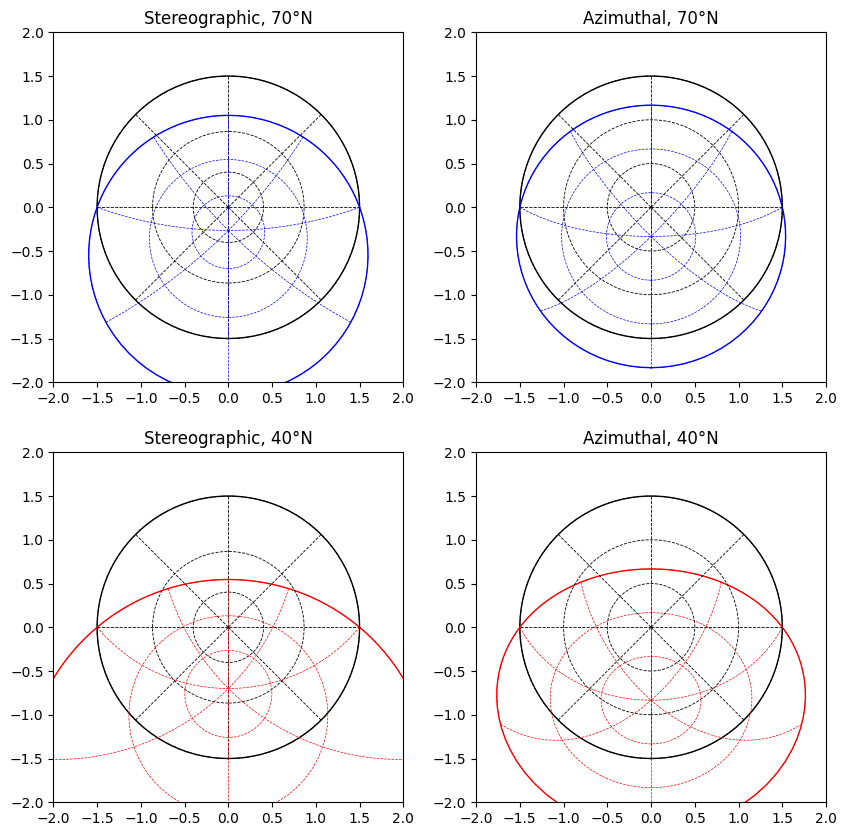

In [2]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(figsize=(10,10), nrows=2, ncols=2)

lat1 = 70
lat2 = 40

phi = np.linspace(0,360,100)
theta = np.full(100,0)

stereo_r = stereo_radius(180)
stereo_scale = 1.5/stereo_r
x,y = stereo_polar(phi, theta)
ax1.plot(stereo_scale*x, stereo_scale*y, 'k', lw=1)
ax3.plot(stereo_scale*x, stereo_scale*y, 'k', lw=1)

azimuth_r = azimuthal_radius(180)
azimuth_scale = 1.5/azimuth_r

x,y = azimuthal_polar(phi, theta)
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)
ax4.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)

x,y = local2equator(phi, theta, lat1, mode='stereo')
ax1.plot(stereo_scale*x, stereo_scale*y, 'b', lw=1)

x,y = local2equator(phi, theta, lat1, mode='azimuth')
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b', lw=1)

x,y = local2equator(phi, theta, lat2, mode='stereo')
ax3.plot(stereo_scale*x, stereo_scale*y, 'r', lw=1)

x,y = local2equator(phi, theta, lat2, mode='azimuth')
ax4.plot(azimuth_scale*x, azimuth_scale*y, 'r', lw=1)  

for i in range(0,90,30):
    
    theta = np.full(100,i)

    x,y = stereo_polar(phi,theta)
    ax1.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)
    ax3.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)

    x,y = azimuthal_polar(phi,theta)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2equator(phi, theta, lat1, mode='stereo')
    ax1.plot(stereo_scale*x, stereo_scale*y, 'b--', lw=0.5)

    x,y = local2equator(phi, theta, lat1, mode='azimuth')
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2equator(phi, theta, lat2, mode='stereo')
    ax3.plot(stereo_scale*x, stereo_scale*y, 'r--', lw=0.5)

    x,y = local2equator(phi, theta, lat2, mode='azimuth')
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'r--', lw=0.5)  

for i in range(0,360,45):
    
    phi = np.full(100,i)
    theta = np.linspace(0,90,100)

    x,y = stereo_polar(phi,theta)
    ax1.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)
    ax3.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)

    x,y = azimuthal_polar(phi,theta)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2equator(phi, theta, lat1, mode='stereo')
    ax1.plot(stereo_scale*x, stereo_scale*y, 'b--', lw=0.5)

    x,y = local2equator(phi, theta, lat1, mode='azimuth')
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2equator(phi, theta, lat2, mode='stereo')
    ax3.plot(stereo_scale*x, stereo_scale*y, 'r--', lw=0.5)

    x,y = local2equator(phi, theta, lat2, mode='azimuth')
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'r--', lw=0.5)   

for ax in (ax1,ax2,ax3,ax4):
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_aspect('equal')

ax1.set_title('Stereographic, 70°N')
ax2.set_title('Azimuthal, 70°N')
ax3.set_title('Stereographic, 40°N')
ax4.set_title('Azimuthal, 40°N')


plt.show()

The Field Of View parameter used in the plots is the angular size of the rete. The required FOV to completely cover up the sky seen by the observer is $2(180°-|lat|)$. For an obeserver at $45°$, the required FOV is $270°$, which introduces a lot of distortion in an azimuthal map and makes a stereographic projection unusable, so usually the FOV is lowered and a part of the sky left uncovered.

Recently, two-sided planispheres have been introduced, which project the local sky dome as seen from both poles. In this way the FOV required to see the whole sky is just 180°, plus a bit more to have an overlap between the views. In this way planispheres work also near the equator.

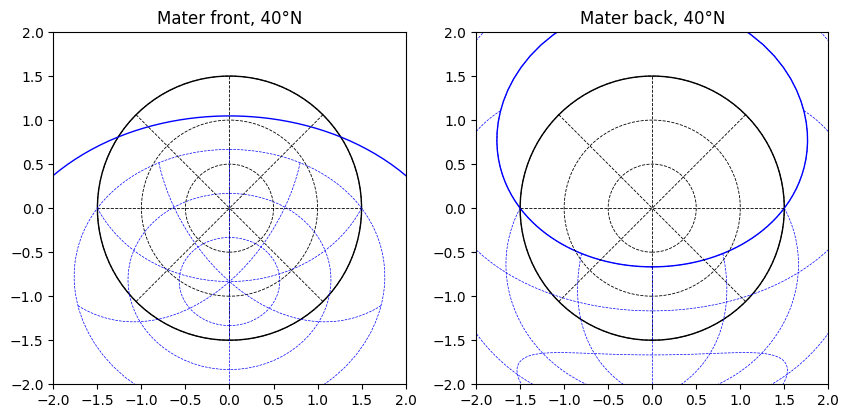

In [3]:
fig, (ax1,ax2) = plt.subplots(figsize=(10,10), nrows=1, ncols=2)

lat1 = 40

phi = np.linspace(0,360,100)
theta = np.full(100,0)

azimuth_r = azimuthal_radius(180)
azimuth_scale = 1.5/azimuth_r

x,y = azimuthal_polar(phi, theta)
ax1.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)

x,y = local2equator(phi, theta, lat1, mode='azimuth', pole='N')
ax1.plot(stereo_scale*x, stereo_scale*y, 'b', lw=1)

x,y = local2equator(phi, theta, lat1, mode='azimuth', pole='S')
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b', lw=1)

for i in range(0,90,30):
    
    theta = np.full(100,i)

    x,y = azimuthal_polar(phi,theta)
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2equator(phi, theta, lat1, mode='azimuth', pole='N')
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2equator(phi, theta, lat2, mode='azimuth', pole='S')
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)  

for i in range(0,360,45):
    
    phi = np.full(100,i)
    theta = np.linspace(0,90,100)

    x,y = azimuthal_polar(phi,theta)
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2equator(phi, theta, lat1, mode='azimuth', pole='N')
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2equator(phi, theta, lat2, mode='azimuth', pole='S')
    if not i==180:
        ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)   

for ax in (ax1,ax2):
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_aspect('equal')

ax1.set_title('Mater front, 40°N')
ax2.set_title('Mater back, 40°N')


plt.show()

## How to make a planisphere

To make a planisphere (or astrolabe, depending on the projection you will use) you will need glue, scissors and cardboard and a paper fastener to join the Mater and the Rete together in the center. Usually the Mater is printed on transparent plastic to make the stars below visible, but different ways to do this exist. The option __MARK_CENTER__ marks with an x where the center of the plot is. 

The HARey module constains the functions __create_planisphere()__ and __create_planisphere_2sided()__ to create Maters and polar maps with the same size.

The FOV of the polar map required to see the whole sky inside the Mater with a one-side planisphere is $2(180-|lat|)$, but you will likely have to use a smaller value as high FOVs make the map unreadable. The default projection is azimuthal: a stereo projection preserves better the shape of the constellations, but is considerably worse for high FOVs.

For two-side planispheres, the FOV is 190°-200° and both projections work fine.

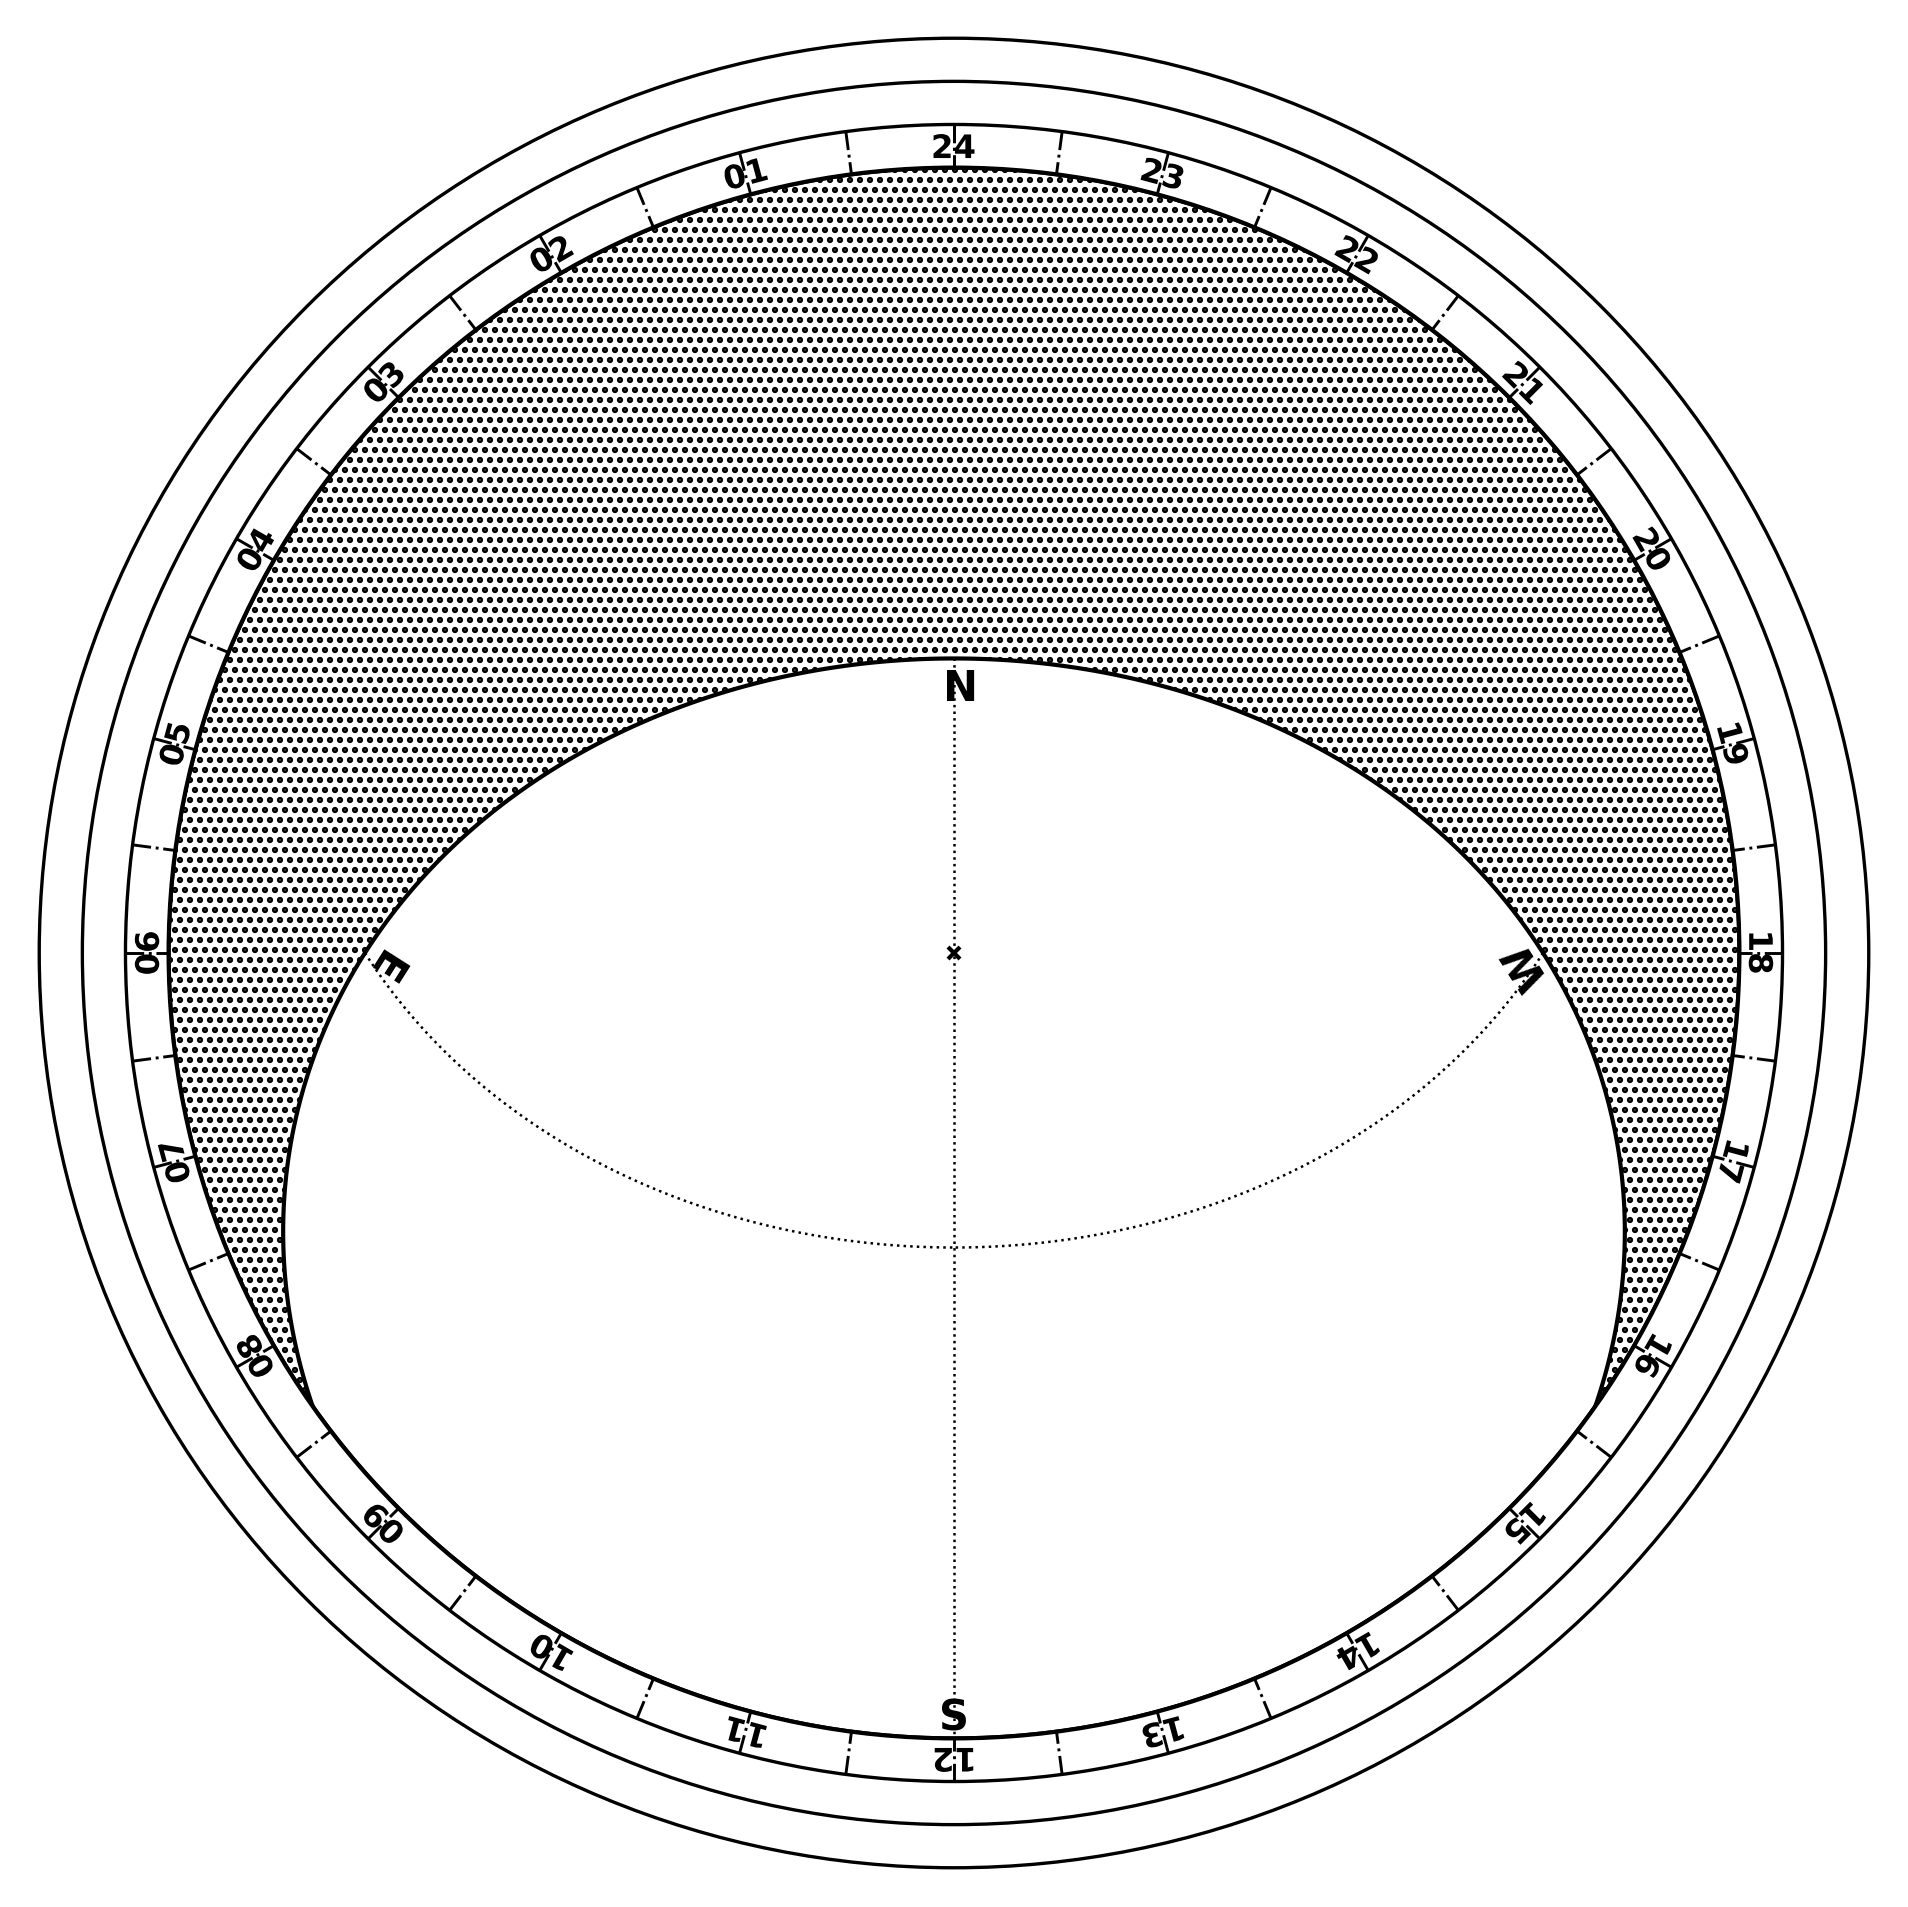

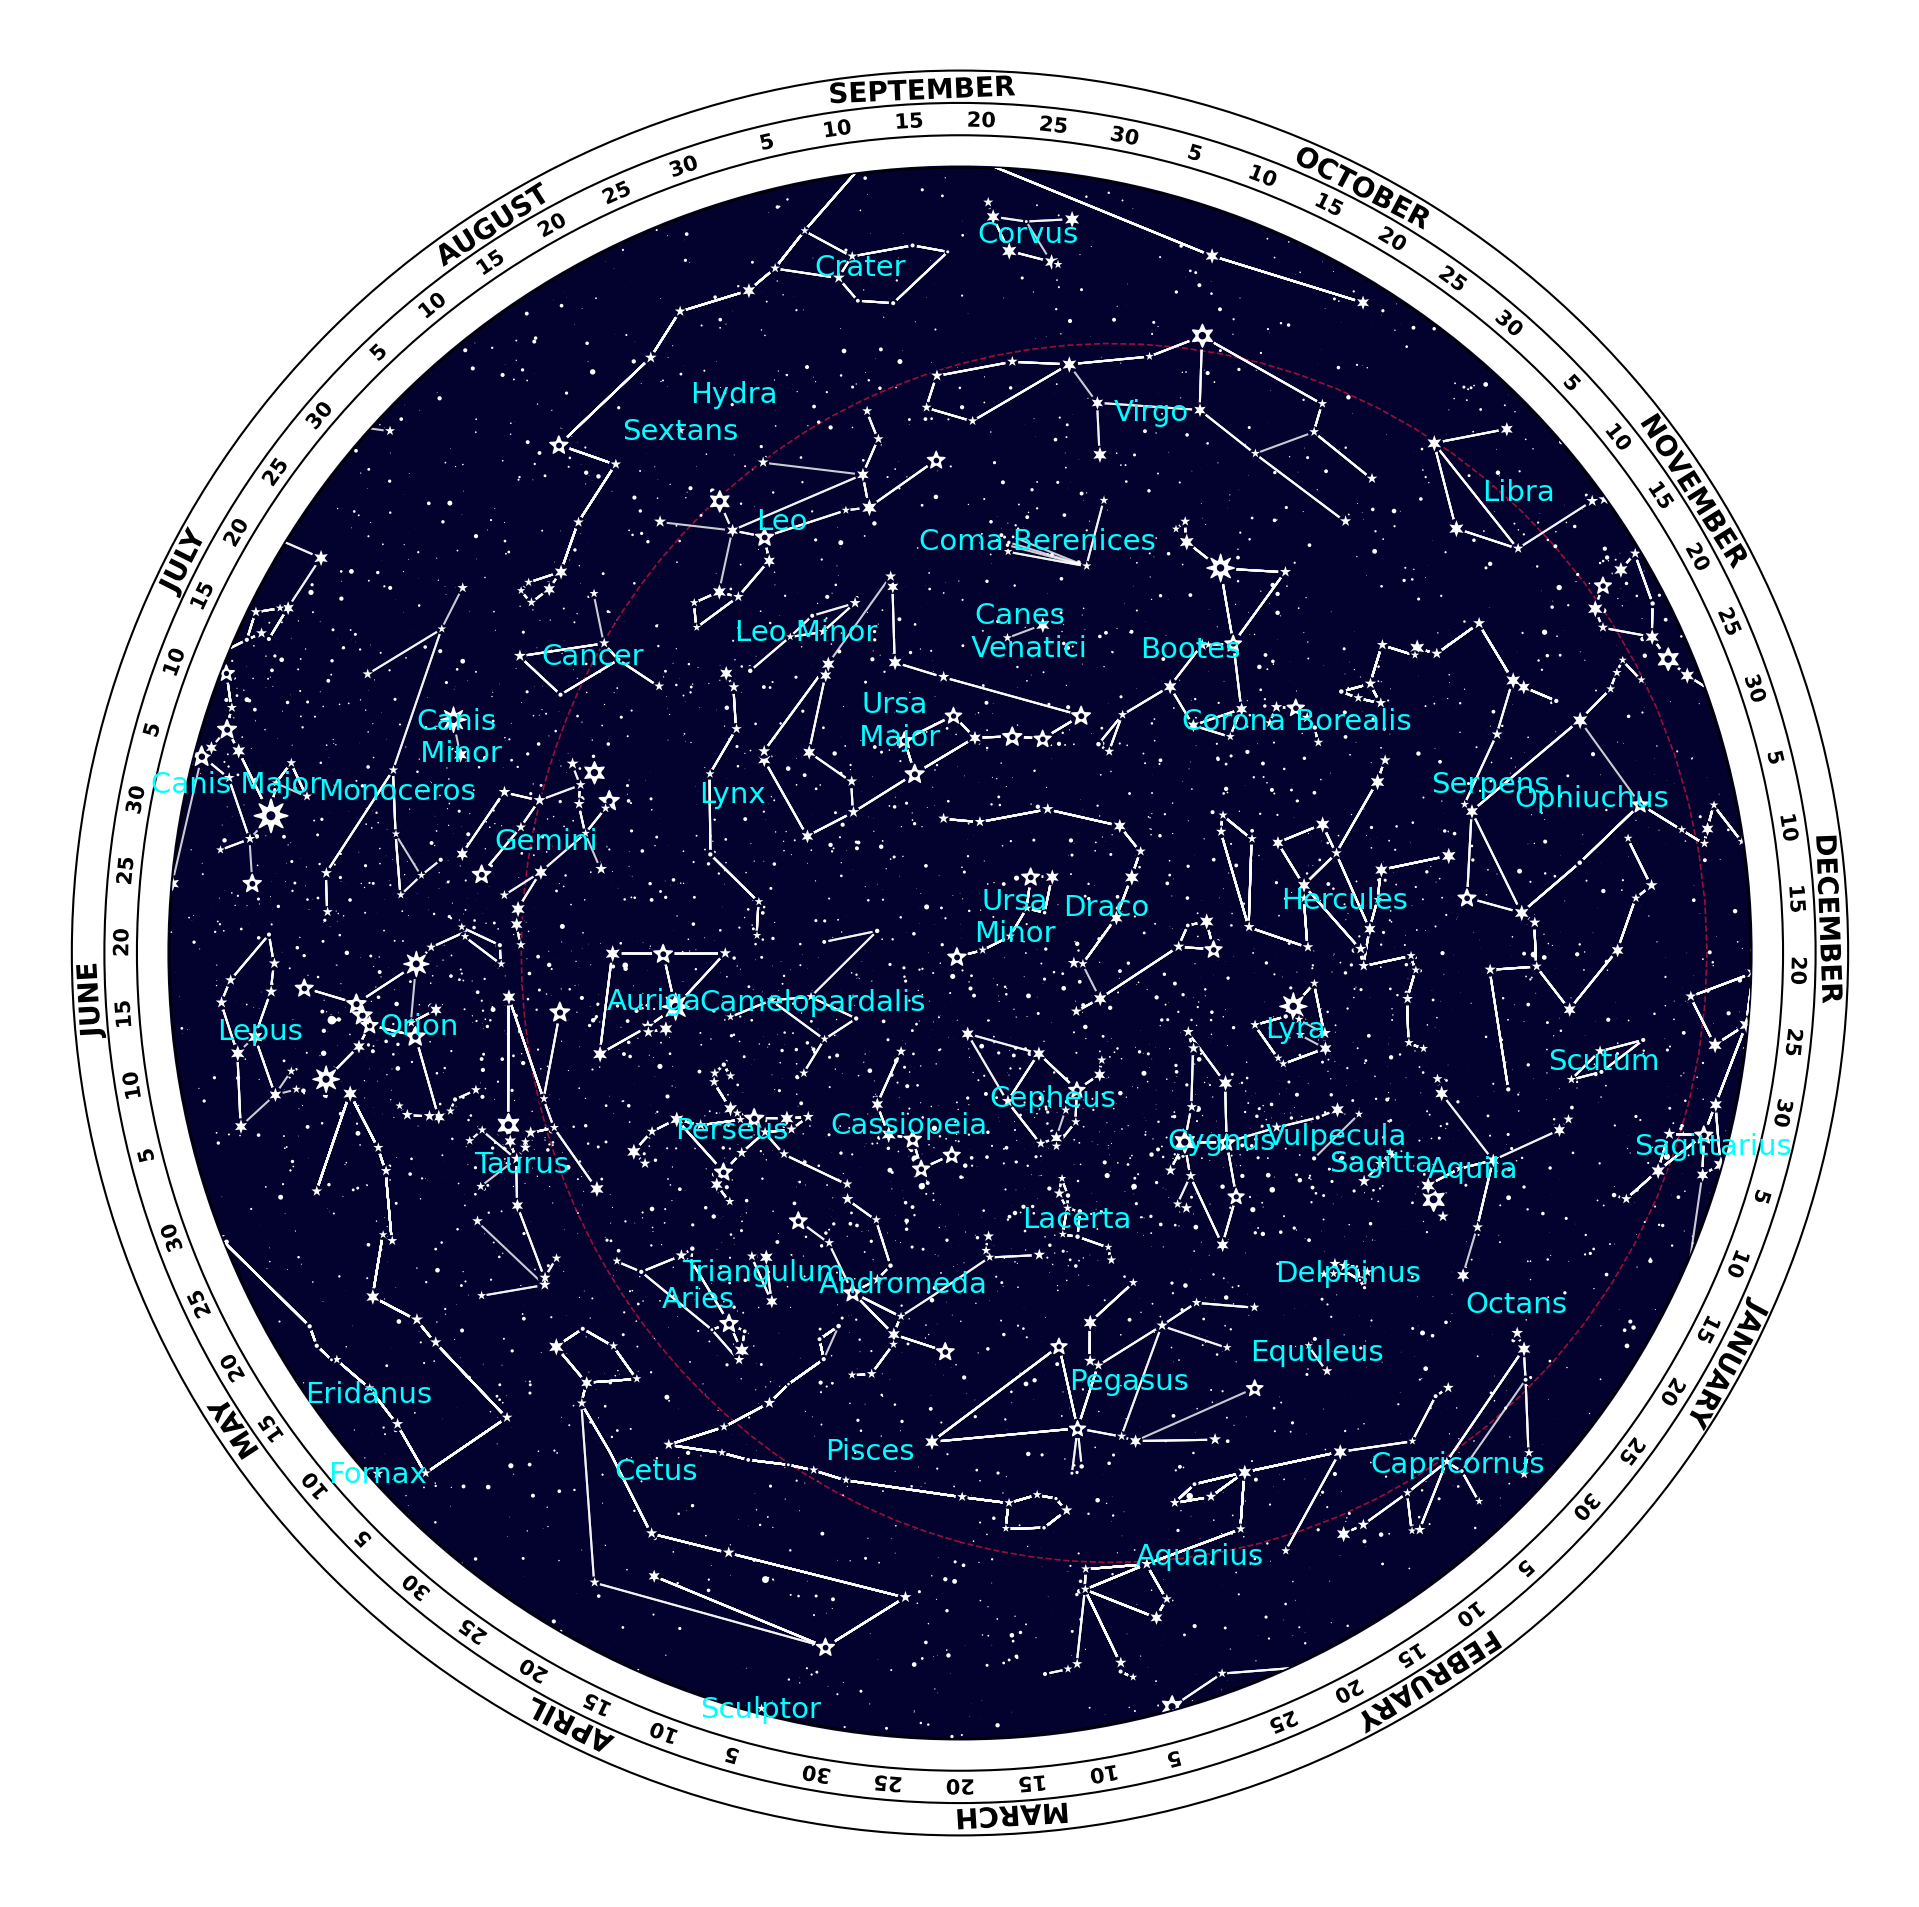

In [4]:
harey.set_flags({'CON_LINES':True, 'CON_NAMES':True})
harey.create_planisphere(lat = 45, FOV=240, save_folder='planisphere', mode='azimuth')

And now a two sided planisphere, to use at 30° S:

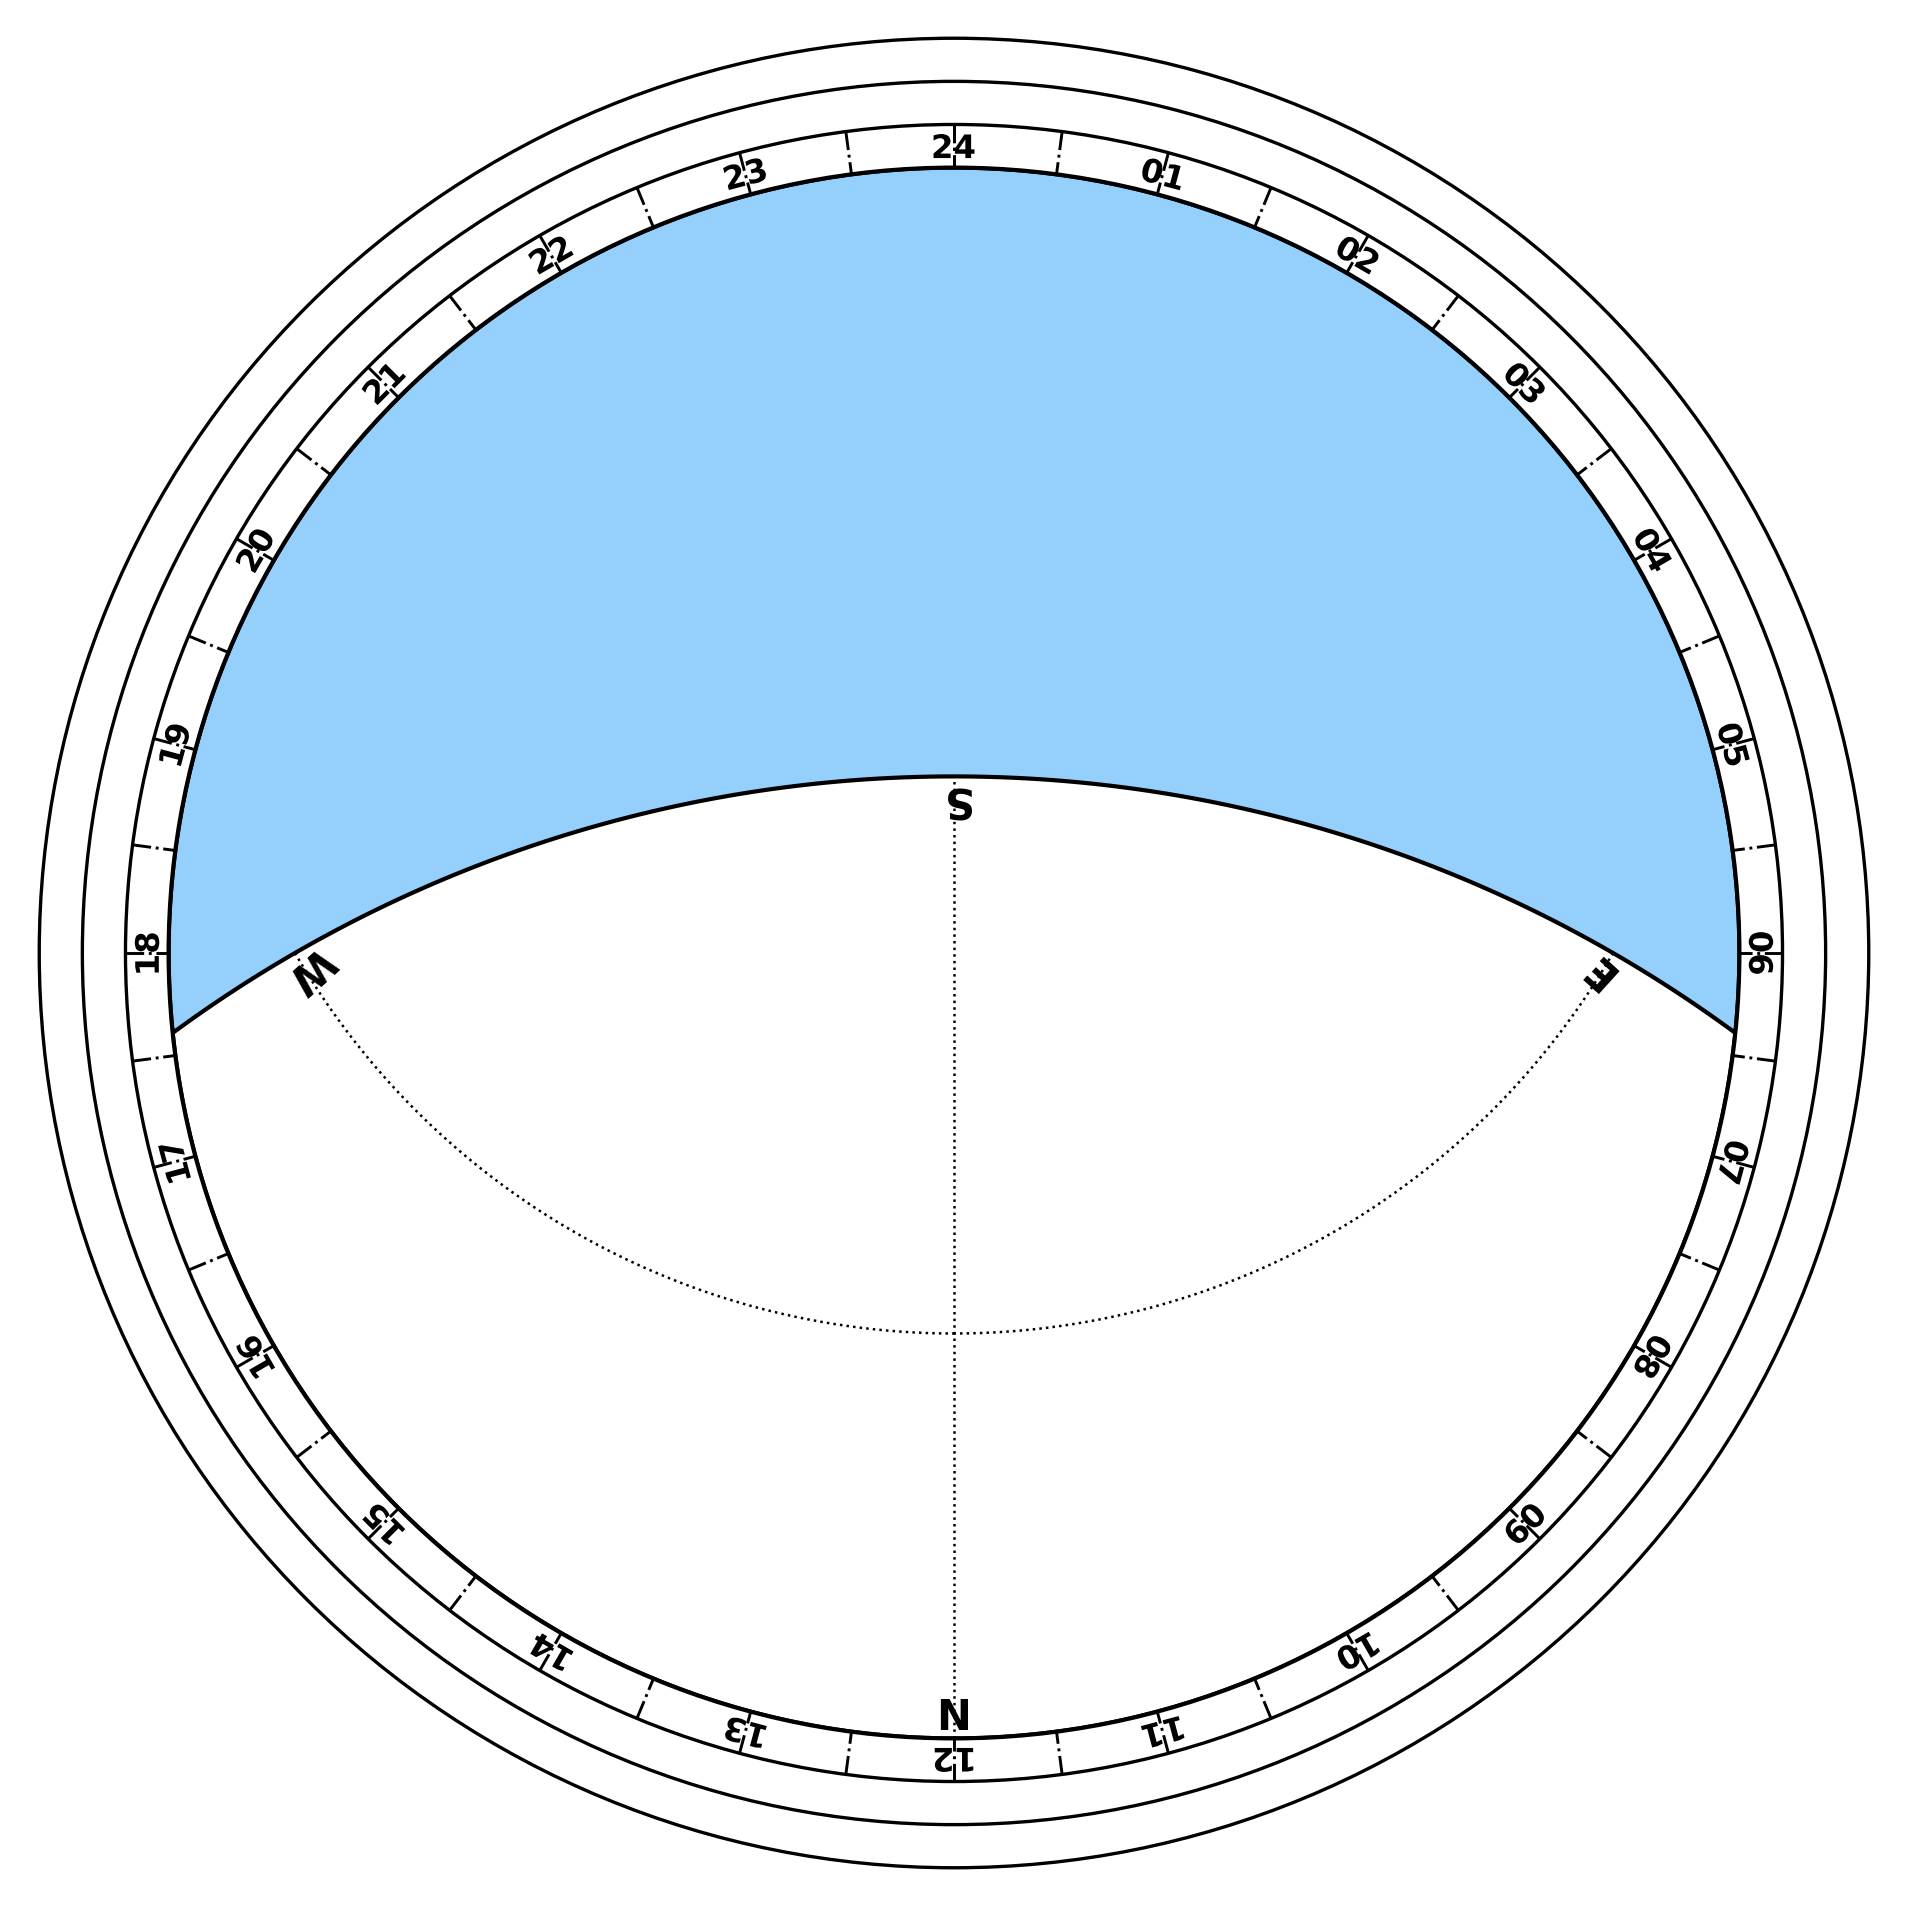

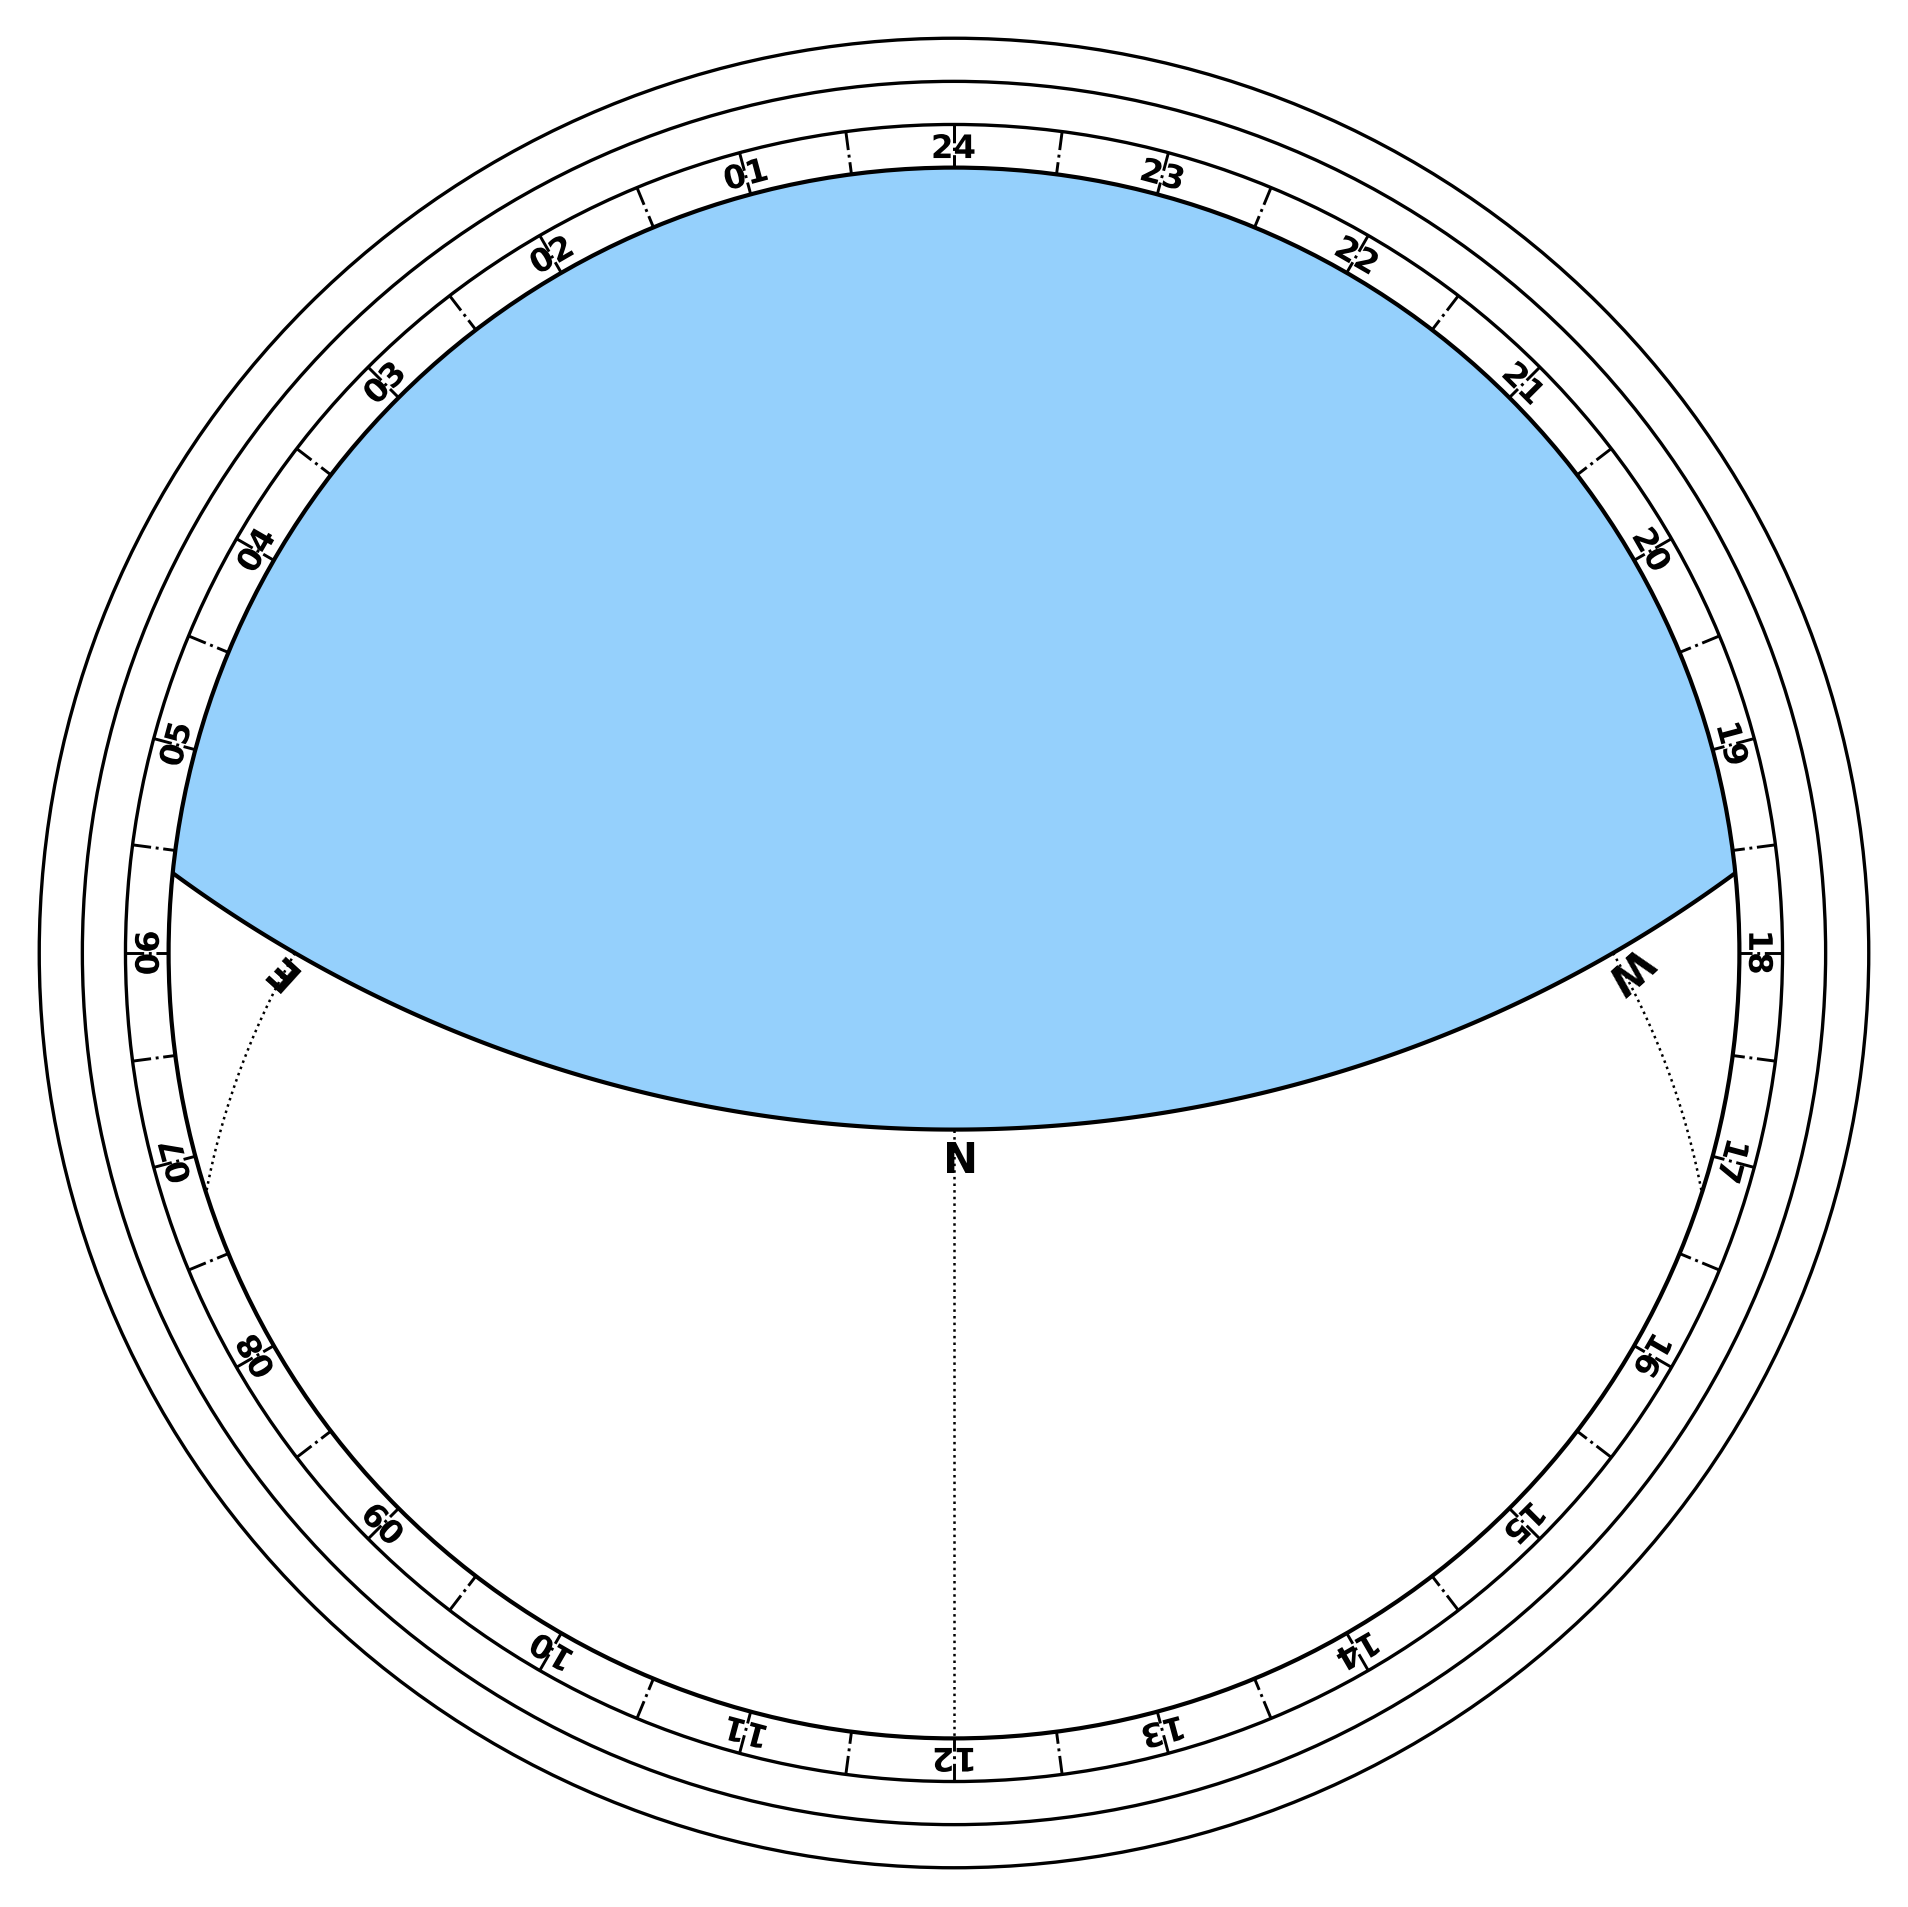

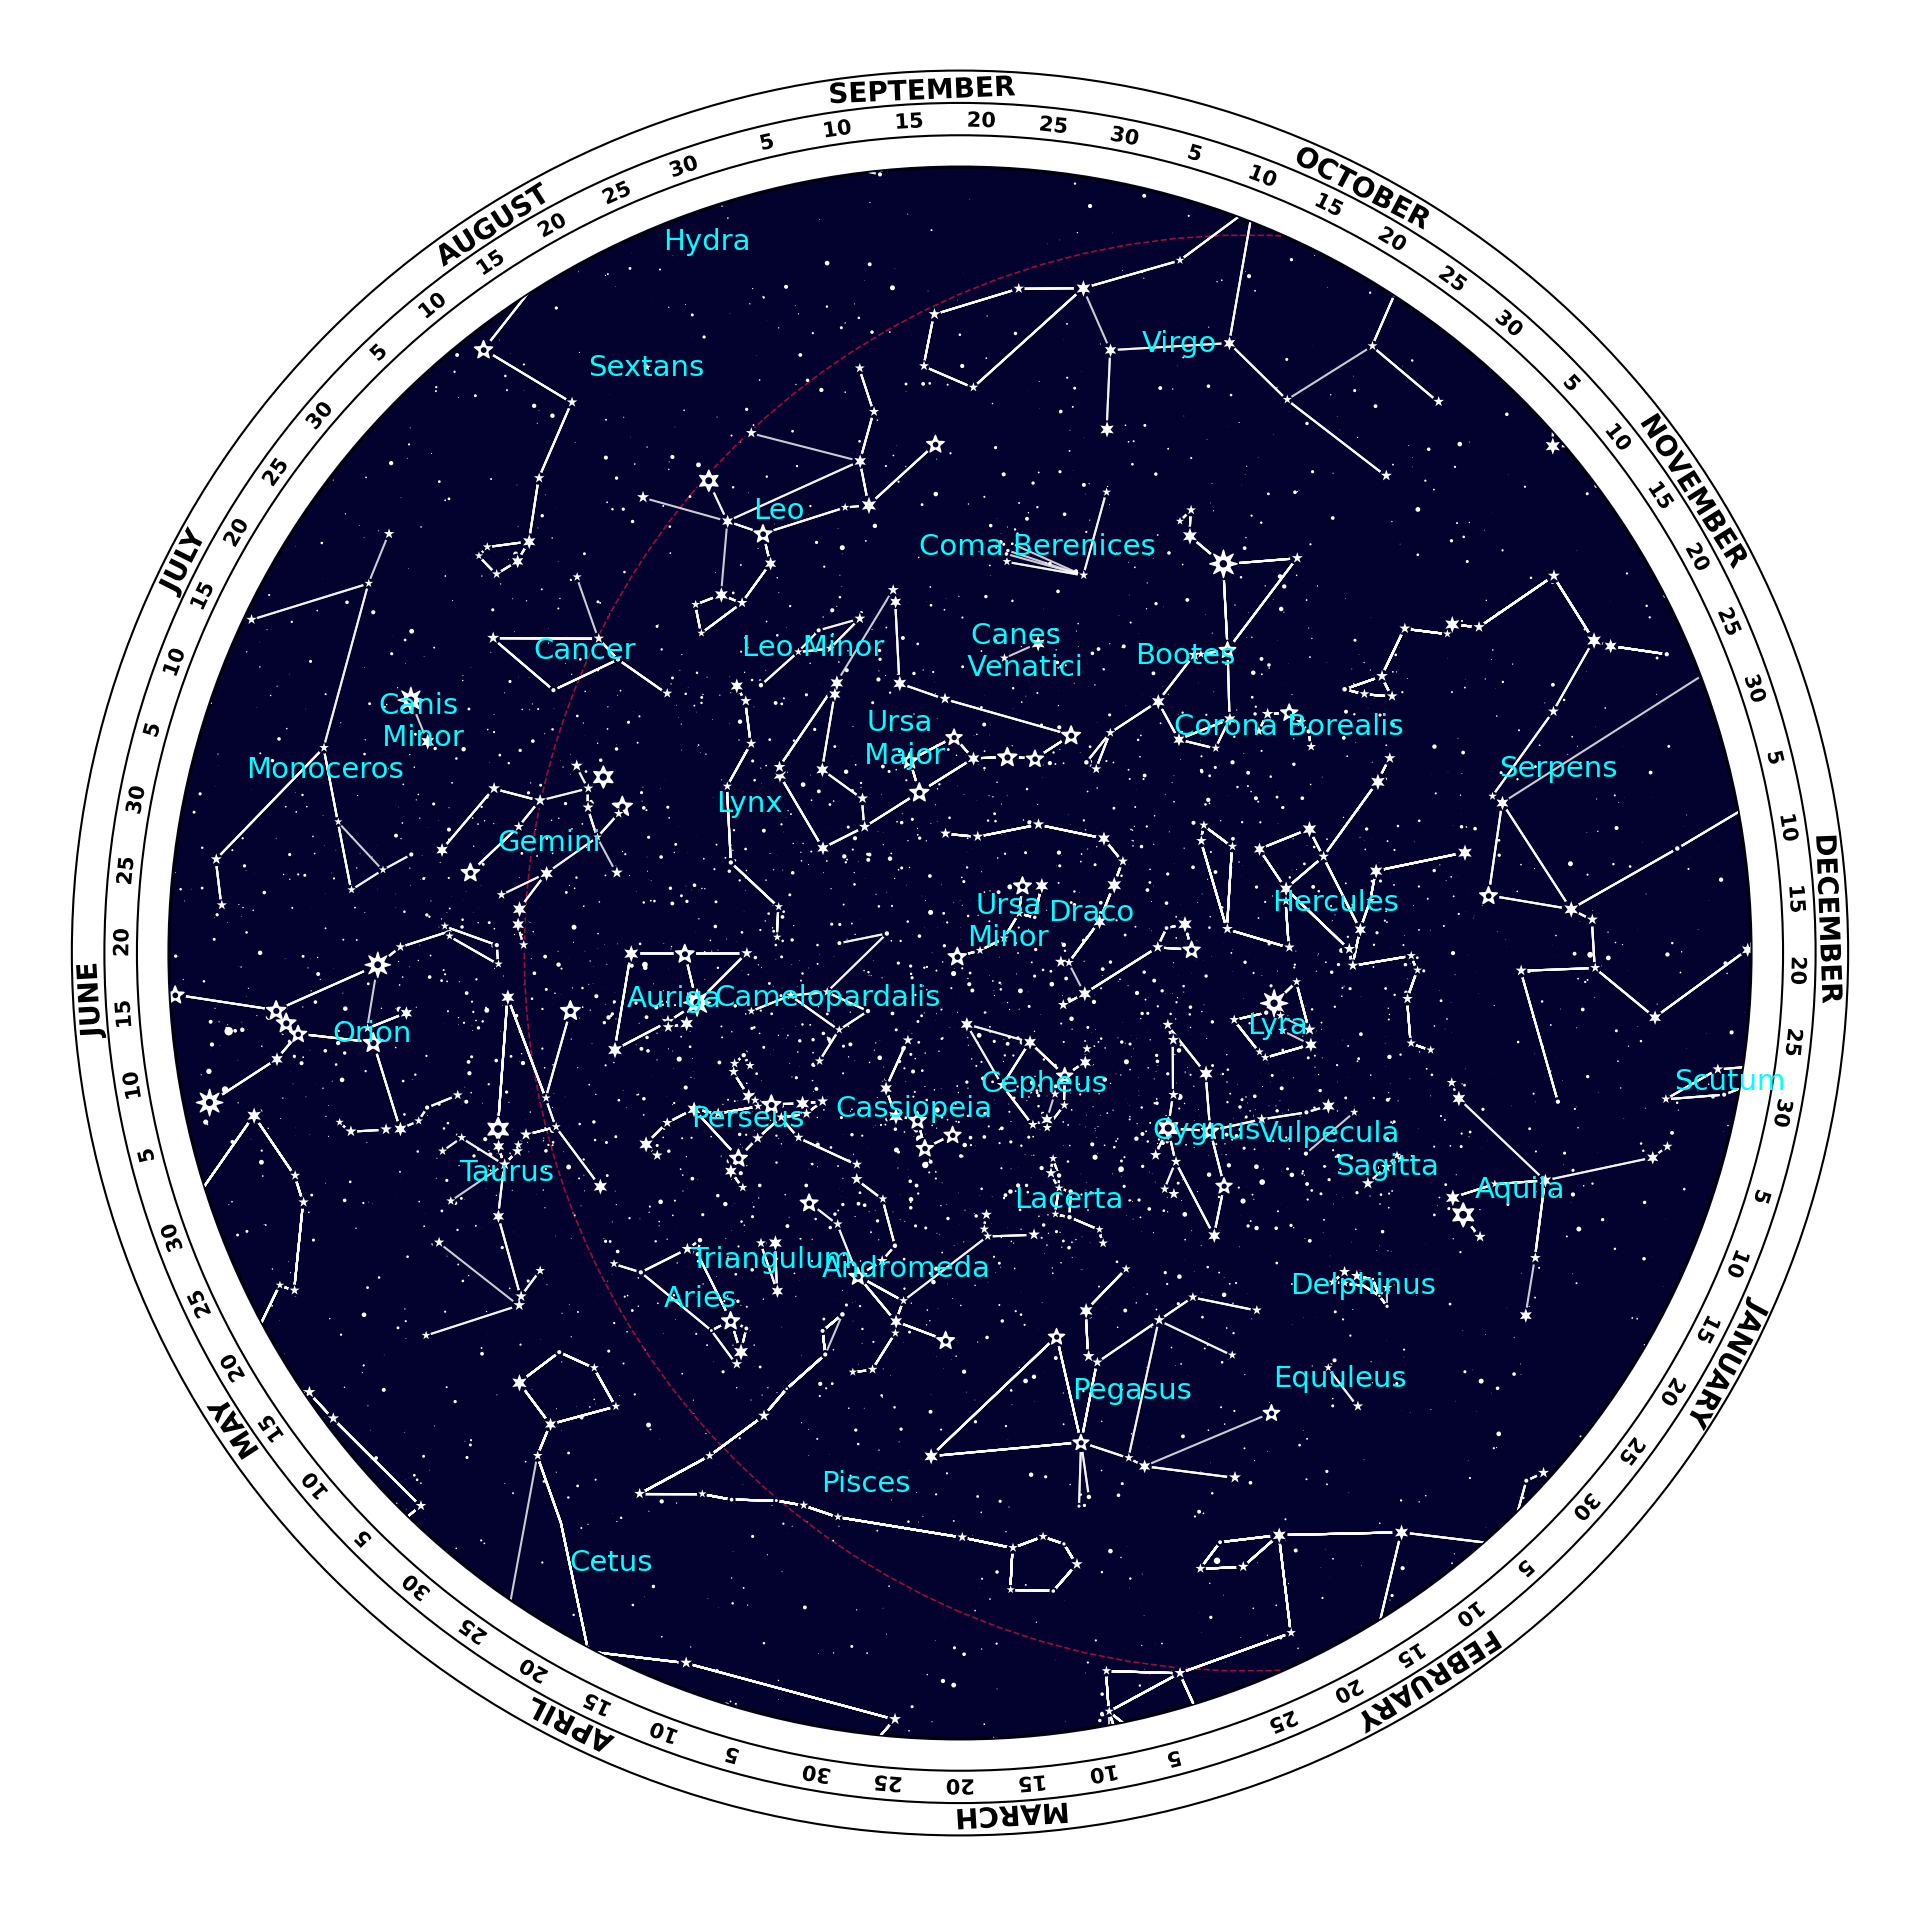

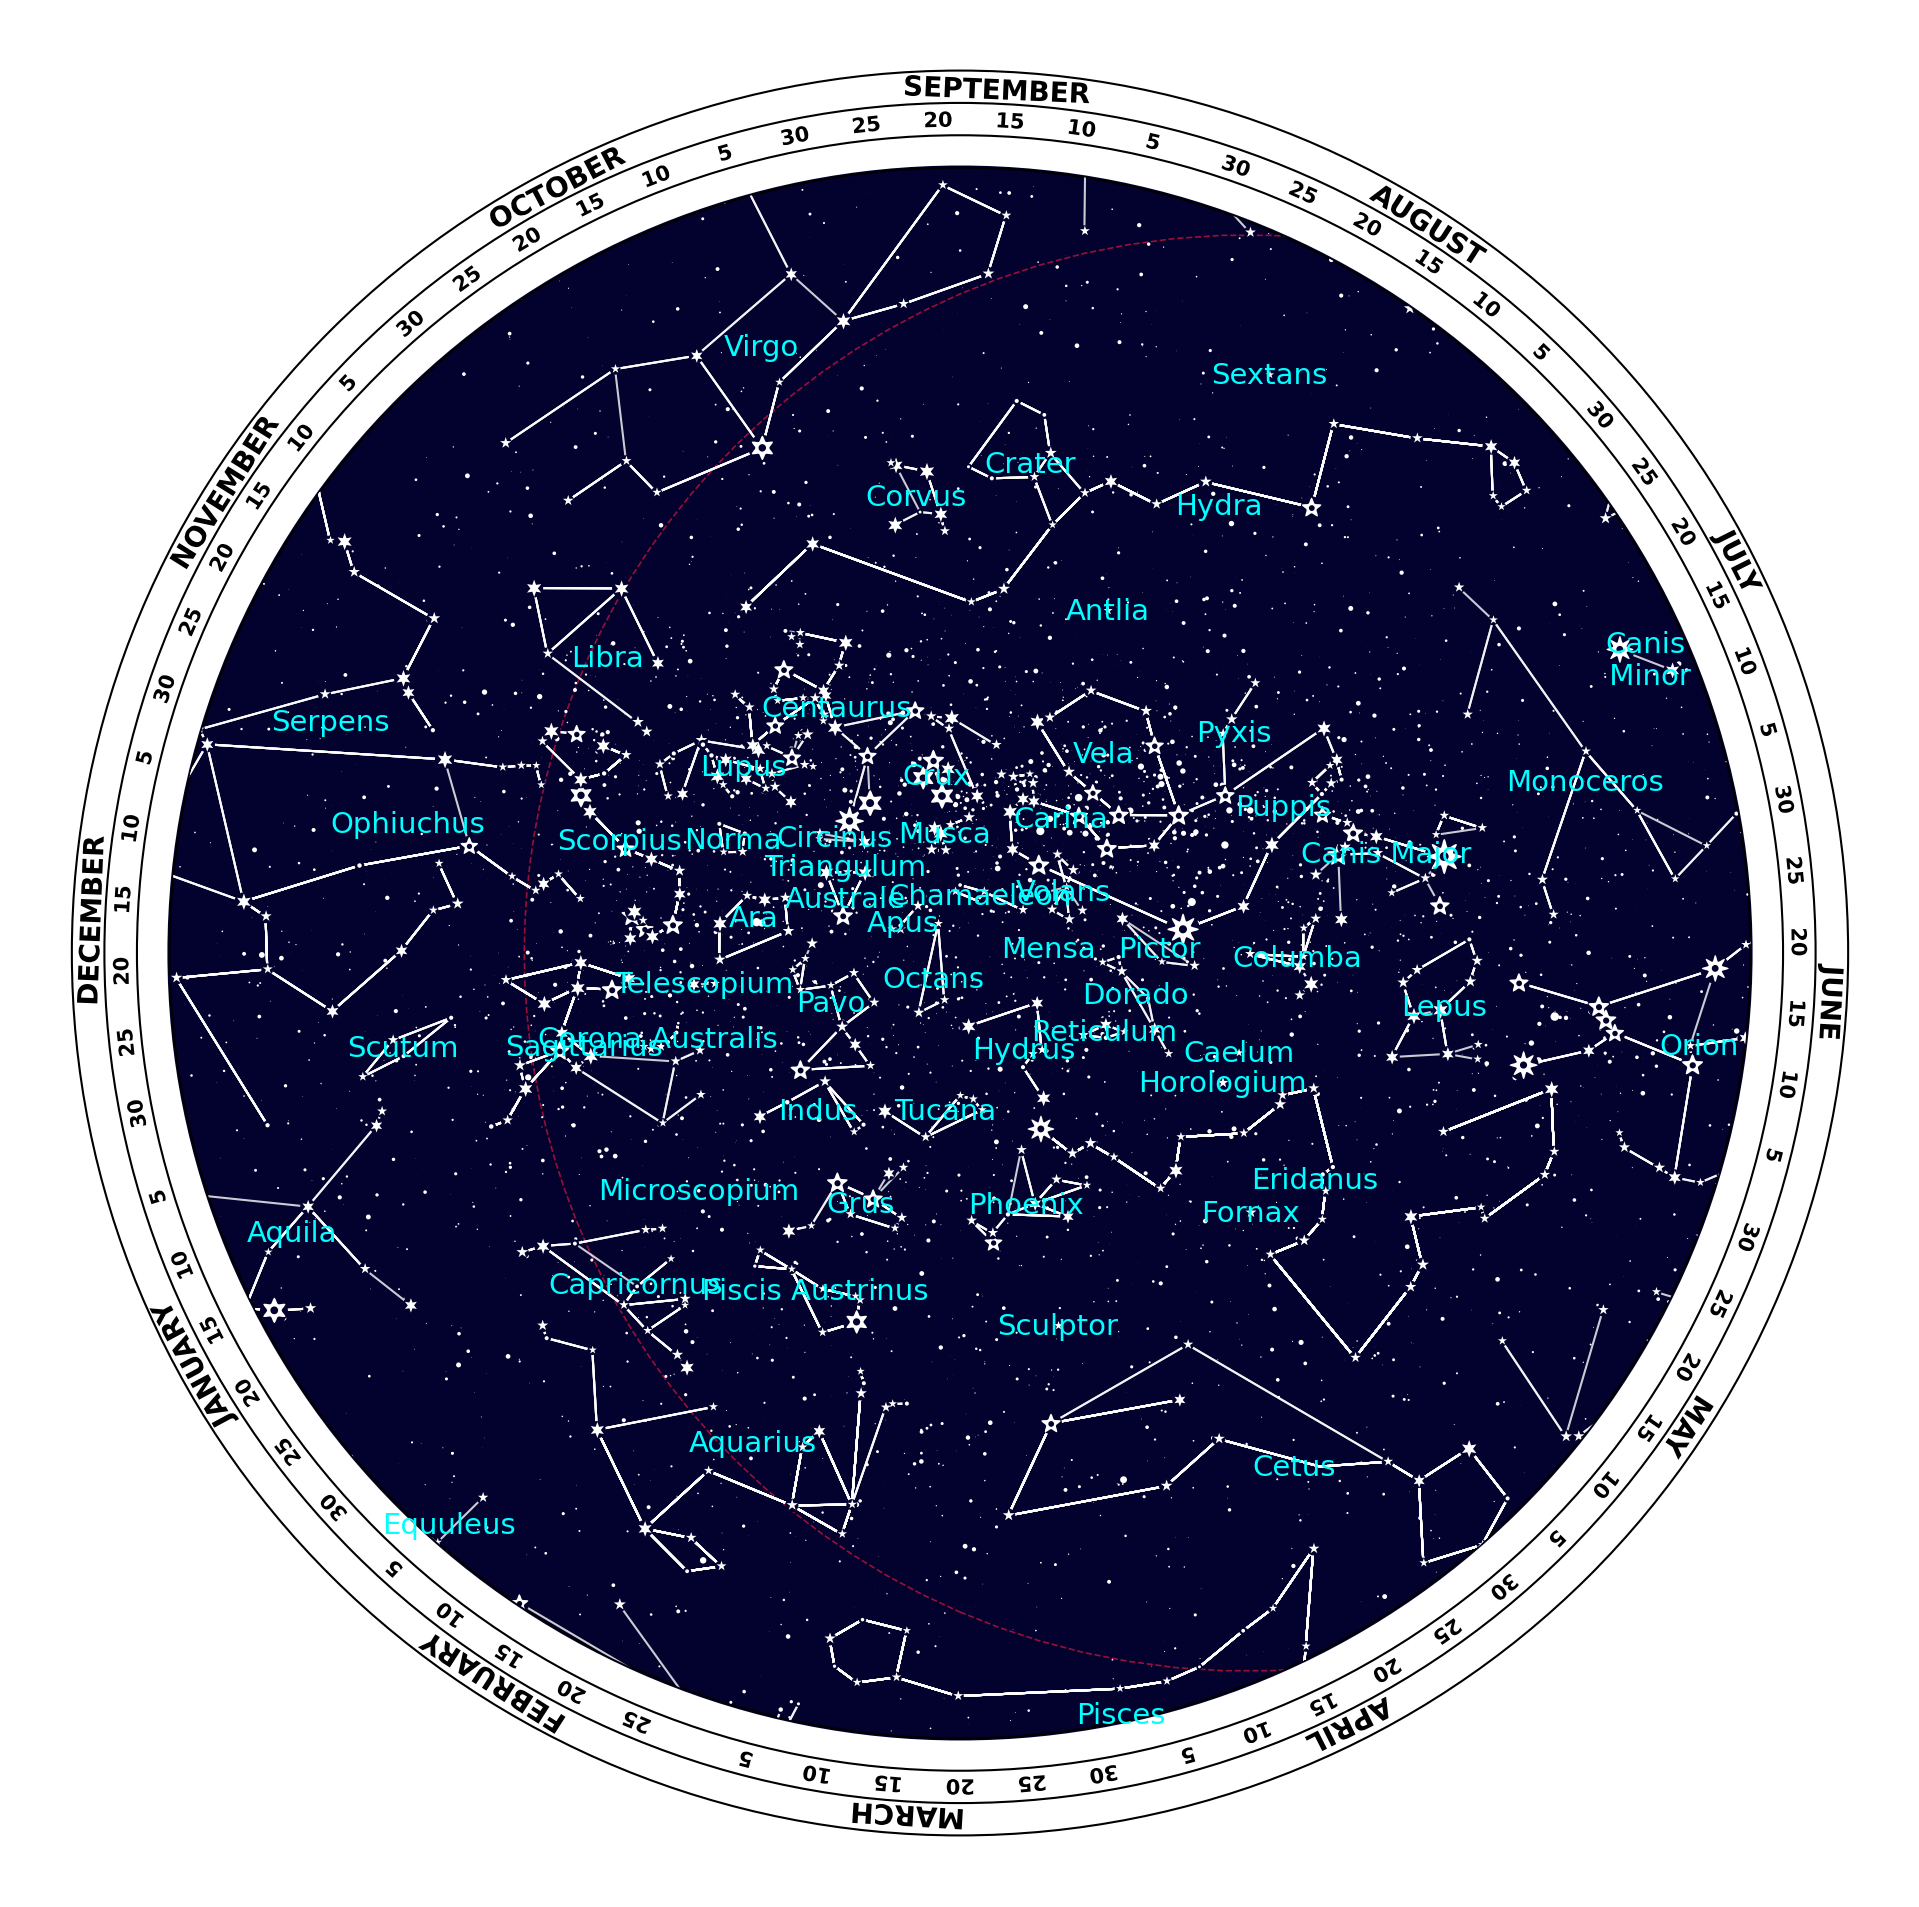

In [5]:
harey.set_flags({'CON_LINES':True, 'CON_NAMES':True})
harey.create_planisphere_2sided(lat = -30, FOV=200, mode='stereo', SOLID_FILL=True, MARK_CENTER=False)

A more minimalistic planisphere

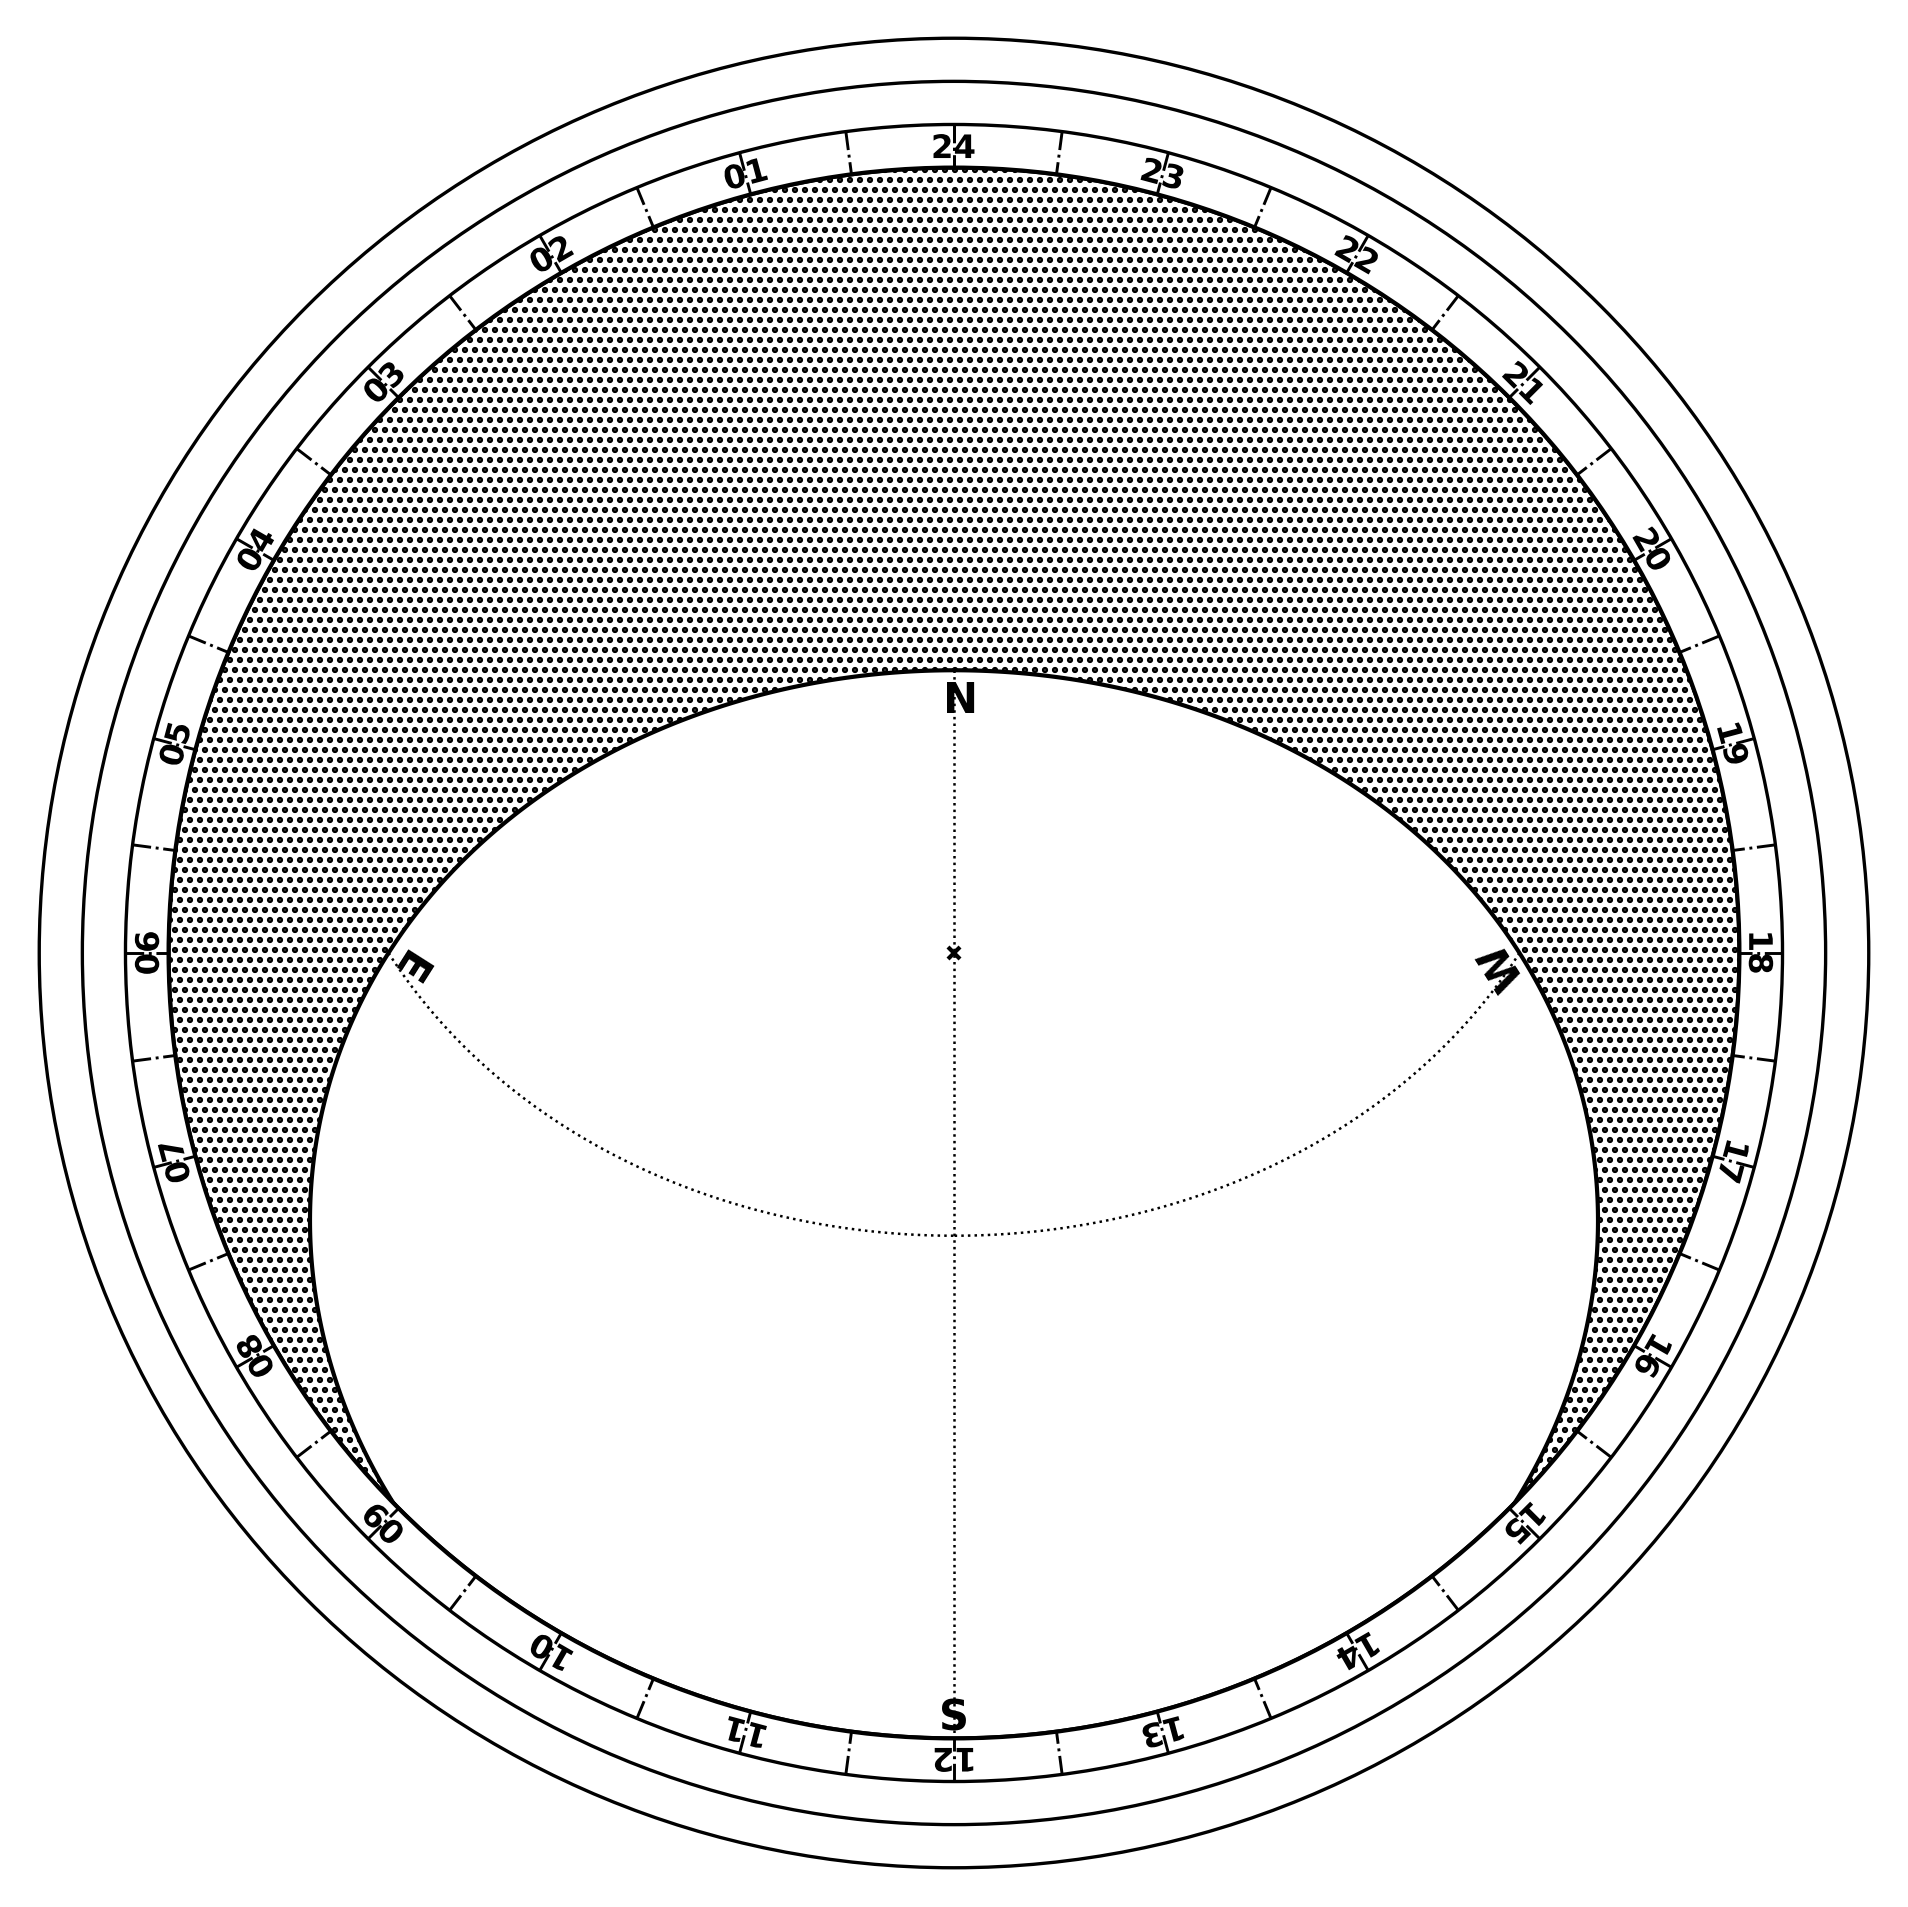

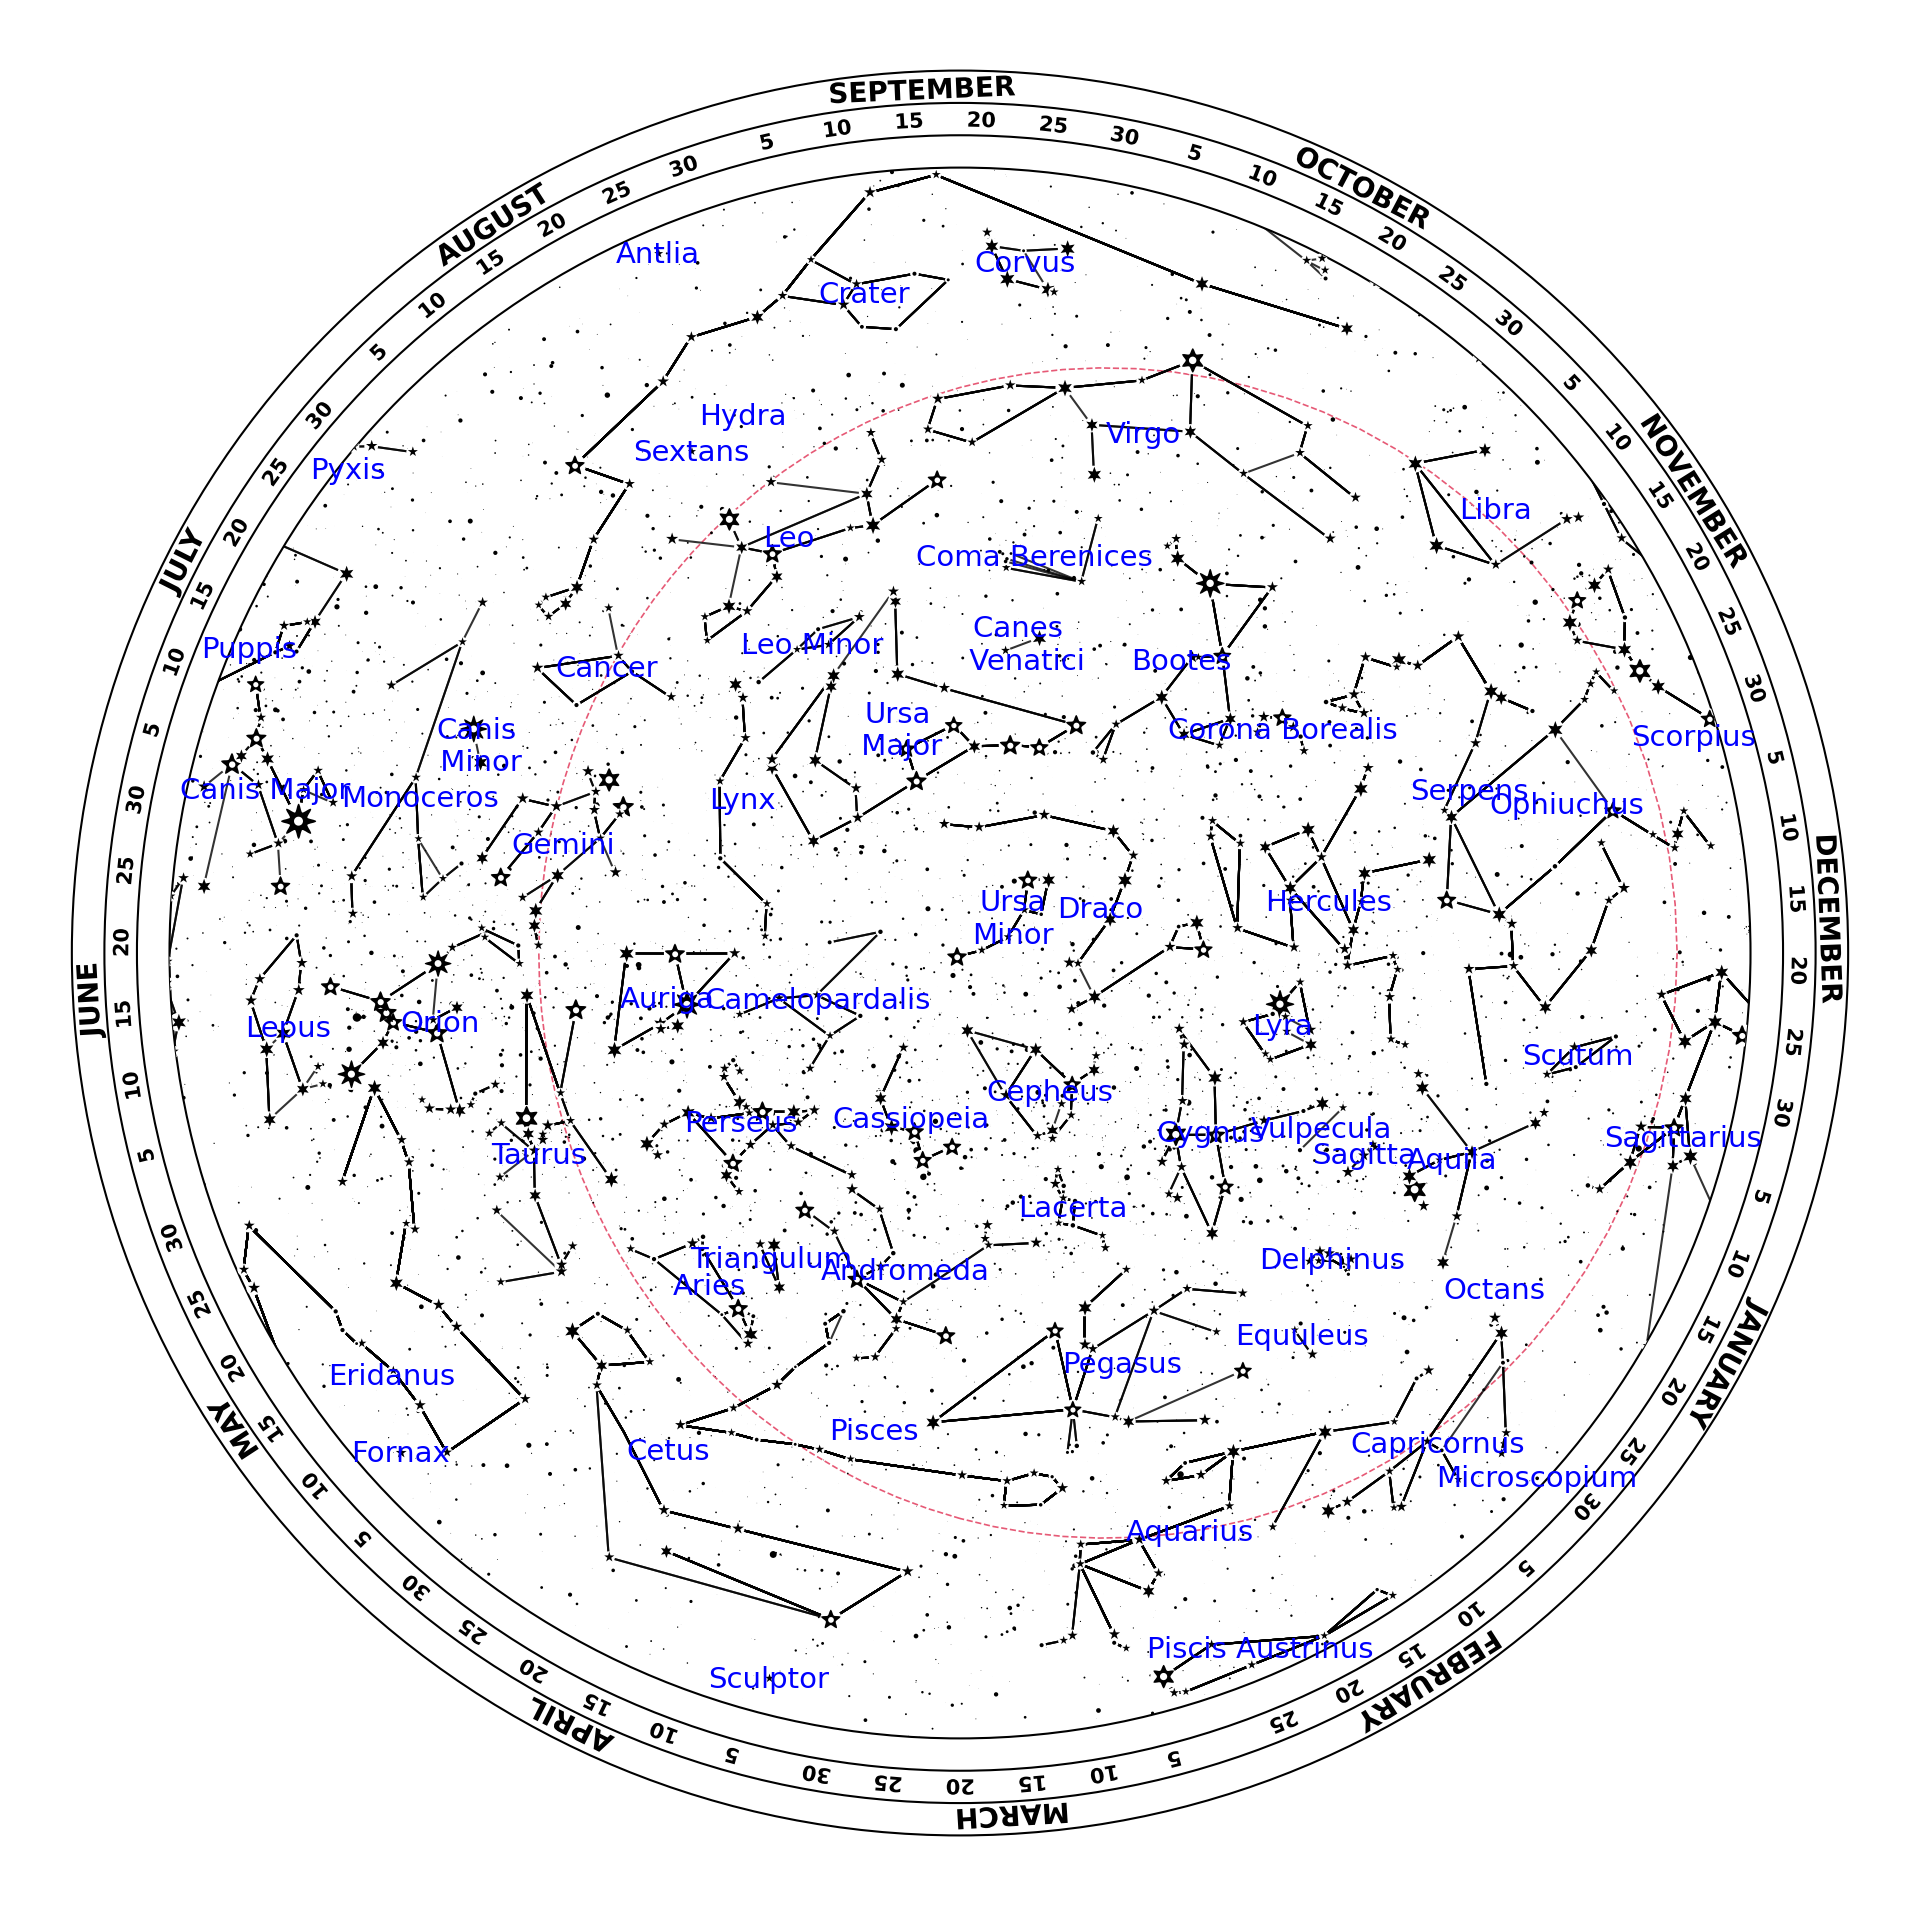

In [8]:
harey.set_flags({'CON_LINES':True, 'CON_NAMES':True})
harey.set_colors({'sky':'white', 'constellations':'k', 'star':'k', 'constellation_labels':'b'})
harey.create_planisphere(lat=45, save_folder='planisphere', FOV=250)

# How to use it
 Historically, the function of an astrolabe was to measure the elevation of stars to compute the local time.
 
 Nowadays that we have wonderful things called clocks, most planispheres are used to predict the visible stars at a certain time and date.

To use a planisphere, set it for the time and date: rotate the Mater or the polar map until the hour on the inner ring is aligned with the day of the month on the outer ring. Now the stars not covered by the Mater are the ones visible in the sky. To find them, hold the planisphere towards the sky, use the cardinal point to orient yourself and rotate the whole planisphere to align the projected horizon on the mother with the real horizon in the direction chosen. If you have done everything correct, you can now start to search fro the constellations in the night sky. 

